# Applied Glaciology - Gruppa Zweiudrisig
## Assignment 1

### Task 1 - Geodetic glacier mass balance

Use the geodetic method for computing the mass balance of Ghiacciaio del Basodino for the period 1994-2021. If you don’t recall what the geodetic method is, refer to the ”Glossary of glacier mass balance and related terms” [1]. To convert the volume change to mass change, you can assume a density of 850 kg $m^{−3}$.

#### Question 1 [6 pts]
How large was the specific mass change rate experienced by the glacier during the period?
Express your result in units of ”m water equivalent per year” (m w.e. $a^{−1}$), and make sure to explain what assumptions you did for computing this number.

In [1]:
###################################
# Setup
###################################

# Import libraries
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Define Paths
path_data_ex01 = "./data_assignment_1/"
path_dem_basodino_1994 = path_data_ex01 + "dem_basodino_1994.asc"
path_dem_basodino_2021 = path_data_ex01 + "dem_basodino_2021.asc"
path_mask_basodino_1994 = path_data_ex01 + "mask_basodino_1994.asc"
path_mask_basodino_2021 = path_data_ex01 + "mask_basodino_2021.asc"

# Example directory:
print(path_mask_basodino_2021)

# Outputs
path_outputs = "./outputs/"

# Create output directory if it does not exist
if not os.path.exists(path_outputs):
    os.makedirs(path_outputs)

# Saving figures
save_figures = True  # Set to True to save figures, False to not save

./data_assignment_1/mask_basodino_2021.asc


In [2]:
###################################
# Load data
###################################

dem_basodino_1994 = np.loadtxt(path_dem_basodino_1994, skiprows=6) # The skiprows skips 6 metadtat rows in our data file
dem_basodino_2021 = np.loadtxt(path_dem_basodino_2021, skiprows=6) # For example the cell size 10 is indicated. I assume grid cells are 10x10 m.

mask_basodino_1994 = np.loadtxt(path_mask_basodino_1994, skiprows=6)
mask_basodino_2021 = np.loadtxt(path_mask_basodino_2021, skiprows=6)

In [3]:
# Look at the content of this dem (digital elevation model)
dem_basodino_1994 # It is an array of 2D values, each value is the elevation in meters at a specific location. The array is 153x260

array([[2677.9 , 2679.53, 2679.68, ..., 2345.5 , 2347.01, 2349.38],
       [2684.13, 2684.25, 2680.63, ..., 2351.84, 2355.56, 2356.13],
       [2686.43, 2686.01, 2685.98, ..., 2358.53, 2359.93, 2360.31],
       ...,
       [3083.99, 3093.08, 3101.57, ..., 2202.5 , 2192.91, 2185.38],
       [3087.73, 3095.99, 3104.03, ..., 2187.94, 2184.03, 2178.35],
       [3090.03, 3099.91, 3110.28, ..., 2179.03, 2175.67, 2172.5 ]],
      shape=(153, 260))

We probably can assume that none of the cells that is covered by the glacier in 2021, was not also covered in 1994. But we should check it. (Surprsing result)

In [4]:
# Cells covered by the glacier in 2021, but not in 1994
outside_1994 = (mask_basodino_2021 == 1) & (mask_basodino_1994 == 0)

n_outside = np.count_nonzero(outside_1994)
print(f"2021 glacier cells outside the 1994 glacier: {n_outside}")
print(f"Assumption holds: {not outside_1994.any()}") # --> 34 cells that are classified as outside in 1994 are classified inside in 2021.

2021 glacier cells outside the 1994 glacier: 34
Assumption holds: False


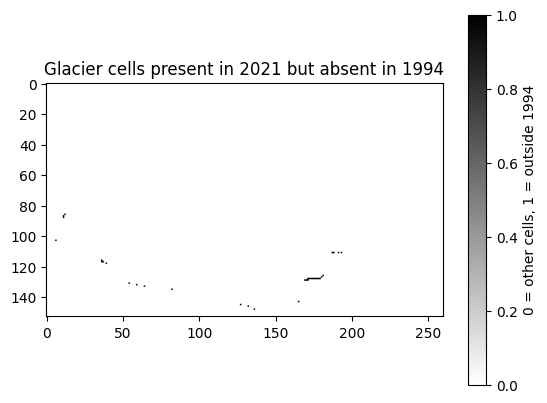

In [5]:
# Show the discussed cells on a plot
plt.imshow(outside_1994, cmap="gray_r")
plt.title("Glacier cells present in 2021 but absent in 1994")
plt.colorbar(label="0 = other cells, 1 = outside 1994")
plt.show()

In [6]:
# Check the reverse: Number of cells that are covered by the glacier in 1994, but not in 2021.
outside_2021 = (mask_basodino_1994 == 1) & (mask_basodino_2021 == 0)
n_outside_2021 = np.count_nonzero(outside_2021)
print(f"1994 glacier cells outside the 2021 glacier: {n_outside_2021}") # 7940 cells (makes sense)


1994 glacier cells outside the 2021 glacier: 7940


In [7]:
# Calculate the height difference between the two DEMs but only where at least one of the DEMs is covered by the glacier (mask == 1)
height_diff = dem_basodino_2021 - dem_basodino_1994
valid_nonzero_before_mask = np.isfinite(height_diff) & (height_diff != 0)
print("Number of non-zero height differences:", np.count_nonzero(valid_nonzero_before_mask))

height_diff = np.where((mask_basodino_1994 == 1) | (mask_basodino_2021 == 1), height_diff, np.nan)
valid_nonzero_after_mask = np.isfinite(height_diff) & (height_diff != 0)
print("Number of non-zero height differences:", np.count_nonzero(valid_nonzero_after_mask))

# Changes where there actually is not a glacier: 
non_glacier_changed_cells = np.count_nonzero(valid_nonzero_before_mask) - np.count_nonzero(valid_nonzero_after_mask)
print(f"Number of non-glacier cells that changed: {non_glacier_changed_cells}") # --> these will be ignored in mass balance

Number of non-zero height differences: 23688
Number of non-zero height differences: 23651
Number of non-glacier cells that changed: 37


In [8]:
# Mass balance calculation: Sum of height differences multiplied by the area of each cell (10x10 m)
area_per_cell = 10 * 10 # 100 m² per cell (see metadata)
volume_difference = np.nansum(height_diff * area_per_cell)  # 100 m² per cell
print(f"Volume difference: {volume_difference} m³")

Volume difference: -49543324.0 m³


In [9]:
# Now we transform volume to mass.
ice_density = 850 # kg/m³
mass_balance_kg = volume_difference * ice_density
print(f"Mass balance: {mass_balance_kg} kg")

# As indicated in the hint we use the average glacier surface area between the two given years
surface_area_1 = np.count_nonzero(mask_basodino_1994) * area_per_cell
surface_area_2 = np.count_nonzero(mask_basodino_2021) * area_per_cell
average_surface_area = (surface_area_1 + surface_area_2) / 2
print(f"Average glacier surface area: {average_surface_area} m²")

# Now we need to get the specific mass change rate
number_of_years = 2021 - 1994 # we need it per year

specific_mass_change_rate = mass_balance_kg / average_surface_area / number_of_years
print(f"Specific mass change rate: {round(specific_mass_change_rate, 0)} kg/m²/year")

# The desired output is the specific mass change rate in m w.e. per year. (Meter Wassersäule)
# We can convert it by dividing by the density of water (1000 kg/m³) --> Assumption we need to make here

water_density = 1000 # kg/m³ ASSUMPTION
specific_mass_change_rate_mwe = specific_mass_change_rate / water_density
print(f"Specific mass change rate: {round(specific_mass_change_rate_mwe, 3)} m w.e./year")

Mass balance: -42111825400.0 kg
Average glacier surface area: 2001800.0 m²
Specific mass change rate: -779.0 kg/m²/year
Specific mass change rate: -0.779 m w.e./year


### Task 2 - Meteorological data

Retrieve a homogenized temperature and precipitation time series in monthly resolution for a meteorological station that you consider to be representative for the glacier. The time series shall cover the period since 1935, since that will be needed later. Note that only a few stations exist with such long-term time series.

Datasource:
https://www.meteoswiss.admin.ch/services-and-publications/applications/ext/download-data-without-coding-skills.html#lang=en&mdt=homogenous&pgid=Temperature&sid=OTL&col=ch.meteoschweiz.ogd-nbcn&di=&tr=&hdr= 


Probably desired variables:
1. rhs150m0 = Precipitation; homogeneous monthly total, in millimetres
2. ths200m0 = Air temperature 2 m above ground; homogeneous monthly mean, in degrees celsius


Stations in the proximity of the glacier but all not homogenized:
- Robièi (ROE) --> Monthly measurements only since 1991
- Cagnoli Diga (CAD) --> Only precipitation
- Prato-Sornico (PSO) --> Only phenology
- Bosco/Gurin (BOS) --> No temperature
- Alpe Quadrella (AQU) --> No temperature
- Cevio (CEC) --> Only phenology
- Cevio (CEV) --> Precipitation since 1900 but temperature only since 1993
- Piotta (PIO) --> Monthly measurements only since 1979



Stations in the proximity of the glacier which are homogenized (4 closest stations with desired variables).  --> in Report list exact heights.
a) Locarno / Monti (OTL) --> supports temperature and precipitation since the desired year (1935) 

b) Grimsel Hospiz (GRH) --> supports temperature and precipitation since the desired year (1935) is elevation-wise a lot closer than Locarno / Monti but is in a different climatic region than the glacier.

c) Andermatt (ANT) --> supports temperature and precipitation since the desired year (1935) is elevation-wise closer than Locarno / Monti Monti but is in a different climatic region than the glacier.

d) S.Bernardino (SBE) --> supports temperature and precipitation since the desired year (1935) is elevation-wise closer than Locarno / Monti and is in the same climatic region as the glacier. Is distance-wise the furthest away. --> Part of Precipitation data missing in 1940's, 1950's

----------------------------------------------------------------
e) Binn (BIN) --> supports air temperature only since 2014

f) Mosogno (MSG) --> No temperature

g) Biasca (BIA) --> No temperature

----------------------------------------------------------------



Climatic Regions of Switzerland: https://www.meteoschweiz.admin.ch/service-und-publikationen/publikationen/berichte-und-bulletins/1980/die-beobachtungsnetze-der-schweizerischen-meteorologischen-ansta.html

Also used and cited in the homgenisation of the data we are using:
https://www.meteoswiss.admin.ch/dam/jcr%3A99793c7a-5b91-47e4-95e4-80459e7e13db/homogenisierungvonklimamessreihenderschweiz.pdf 

Page 31 also mentions that good height similarity is more important than spatial closeness for temperature (but we do correct linearly for temperature with the provided formula --> it doesn't matter too much) What we don't do is correcting the precipitation.

--> we decide for Locarno / Monti (OTL)

# No z Bespreche
Mir chennd no disskutiere welli Referenzstation mer genau wennd nutze und wie usfüehrlich eusi Begründig sell si. Eb nur qualitativ oder au quantitativ.

#### San Bernardino (see missing data)

In [10]:
# Read homogenized temperature and precipitation data
path_data_SBE = path_data_ex01 + "data_SBE.csv" # Data from San Bernardino
data_SBE = pd.read_csv(path_data_SBE, delimiter=";", skiprows=0) 

# Inspect the data
data_SBE.head()

,station_abbr,reference_timestamp,ths2dymn,ths2dymx,ths200m0,th9120mv,th91dnmv,th91dxmv,ths00nm0,pva2hsm0,...,rhs001m0,ths35xm0,rhs150m0,rh9120mv,ghs000m0,gh9120mv,shs000m0,sh9120mv,xhs00om0,xhs012m0
0,SBE,01.01.1864 00:00,NaN,NaN,-6.1,-2.5,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,SBE,01.02.1864 00:00,NaN,NaN,-5.7,-2.4,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,SBE,01.03.1864 00:00,NaN,NaN,-2.3,-1.8,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,SBE,01.04.1864 00:00,NaN,NaN,0.5,-2.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,SBE,01.05.1864 00:00,NaN,NaN,5.8,-1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
###################################
# Select desired data
###################################

# Keep only the relevant columns
data_SBE = data_SBE[["reference_timestamp", "rhs150m0", "ths200m0"]]

# Format is mixed at 1900, so we need to create a date range and assign it to the dataframe. Then we can filter the years we want.
dates = pd.date_range(start="1864-01-01", end="2026-09-01", freq="MS")

data_SBE["reference_timestamp"] = dates

# Select dseired years (1935-2021) and create a copy of the filtered dataframe
data_SBE = data_SBE.loc[
    data_SBE["reference_timestamp"].dt.year.between(1935, 2021)
].copy()

# Inspect the data
data_SBE.head()

,reference_timestamp,rhs150m0,ths200m0
852,1935-01-01,26.6,-7.7
853,1935-02-01,146.9,-4.7
854,1935-03-01,2.9,-4.2
855,1935-04-01,145.2,0.0
856,1935-05-01,133.3,3.3


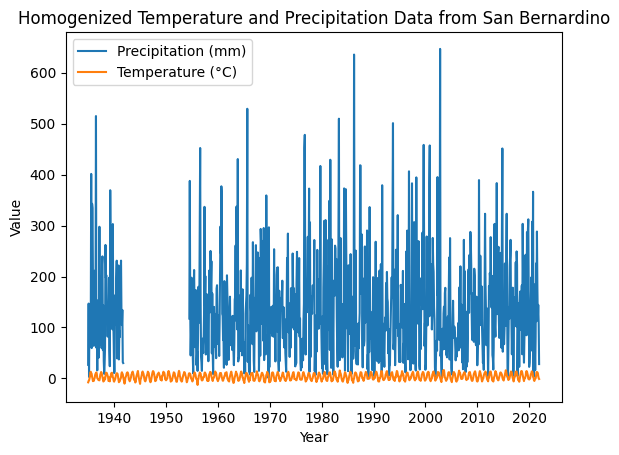

In [12]:
# Quick plot to check data availability
plt.plot(data_SBE["reference_timestamp"], data_SBE["rhs150m0"], label="Precipitation (mm)")
plt.plot(data_SBE["reference_timestamp"], data_SBE["ths200m0"], label="Temperature (°C)")
plt.title("Homogenized Temperature and Precipitation Data from San Bernardino")
plt.xlabel("Year")
plt.ylabel("Value")
plt.legend()    

#### Locarno / Monti (OTL)

In [13]:
# Read homogenized temperature and precipitation data
path_data_OTL = path_data_ex01 + "data_OTL.csv" # Data from San Bernardino
data_OTL = pd.read_csv(path_data_OTL, delimiter=";", skiprows=0) 

# Inspect the data
data_OTL.head()

,station_abbr,reference_timestamp,ths2dymn,ths2dymx,ths200m0,th9120mv,th91dnmv,th91dxmv,ths00nm0,pva2hsm0,...,rhs001m0,ths35xm0,rhs150m0,rh9120mv,ghs000m0,gh9120mv,shs000m0,sh9120mv,xhs00om0,xhs012m0
0,OTL,01.12.1882 00:00,NaN,NaN,3.9,-0.5,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,OTL,01.01.1883 00:00,NaN,NaN,2.5,-1.4,NaN,NaN,NaN,NaN,...,NaN,NaN,166.9,240.0,NaN,NaN,NaN,NaN,NaN,NaN
2,OTL,01.02.1883 00:00,NaN,NaN,6.4,1.2,NaN,NaN,NaN,NaN,...,NaN,NaN,45.8,71.0,NaN,NaN,NaN,NaN,NaN,NaN
3,OTL,01.03.1883 00:00,NaN,NaN,4.3,-5.0,NaN,NaN,NaN,NaN,...,NaN,NaN,65.9,69.0,NaN,NaN,NaN,NaN,NaN,NaN
4,OTL,01.04.1883 00:00,NaN,NaN,10.2,-2.4,NaN,NaN,NaN,NaN,...,NaN,NaN,157.3,95.0,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
# Keep only the relevant columns
data_OTL = data_OTL[["reference_timestamp", "rhs150m0", "ths200m0"]]

# Keep only the relevant years

# Format is mixed at 1900, so we need to create a date range and assign it to the dataframe. Then we can filter the years we want.
dates = pd.date_range(start="1882-12-01", end="2026-09-01", freq="MS")

data_OTL["reference_timestamp"] = dates

# Select dseired years (1935-2021) and create a copy of the filtered dataframe
data_OTL = data_OTL.loc[
    data_OTL["reference_timestamp"].dt.year.between(1935, 2021)
].copy()

# Inspect the data
data_OTL.head()

,reference_timestamp,rhs150m0,ths200m0
625,1935-01-01,8.7,1.9
626,1935-02-01,118.3,5.2
627,1935-03-01,5.3,7.5
628,1935-04-01,102.0,10.3
629,1935-05-01,247.9,12.1


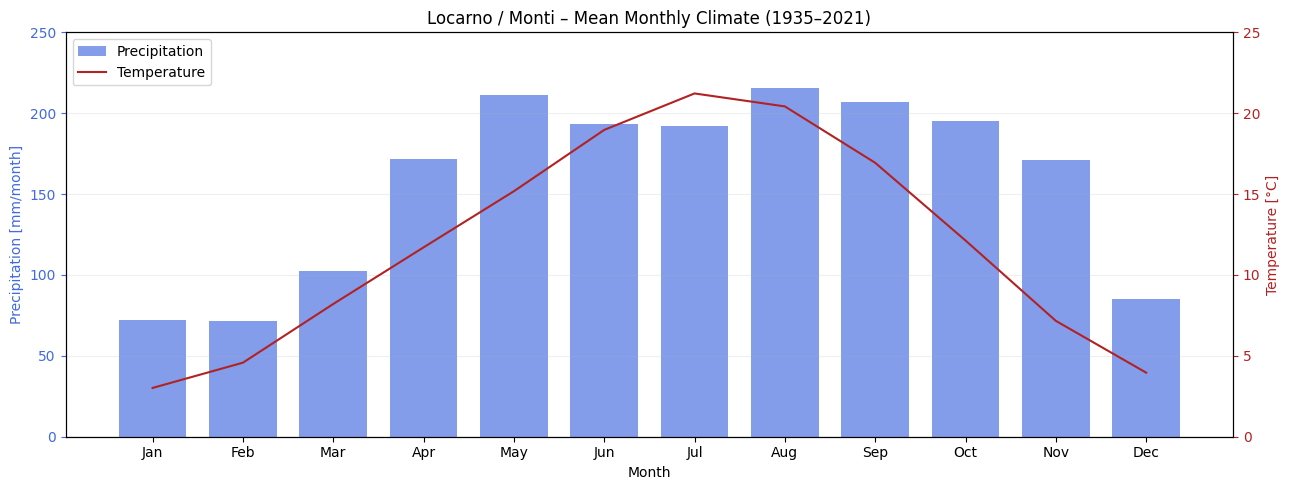

In [15]:
# Prepare data
df = data_OTL.copy()
df["reference_timestamp"] = pd.to_datetime(df["reference_timestamp"])
df = df.sort_values("reference_timestamp").set_index("reference_timestamp")

precip = "rhs150m0"
temp = "ths200m0"
df[[precip, temp]] = df[[precip, temp]].apply(
    pd.to_numeric, errors="coerce"
)
period = f"{df.index.year.min()}–{df.index.year.max()}"

# Calculate mean monthly climate across all available years
monthly = df.groupby(df.index.month)[[precip, temp]].mean()
monthly = monthly.reindex(range(1, 13))

# Plot precipitation and temperature
fig, ax_p = plt.subplots(figsize=(13, 5))
ax_t = ax_p.twinx()

bars = ax_p.bar(
    monthly.index, monthly[precip], width=0.75,
    color="royalblue", alpha=0.65, label="Precipitation"
)
line, = ax_t.plot(
    monthly.index, monthly[temp],
    color="firebrick", linewidth=1.5, label="Temperature"
)

# Scale both axes and align their zero lines
t_min = min(0, 5 * np.floor((monthly[temp].min() - 1) / 5))
t_max = max(5, 5 * np.ceil((monthly[temp].max() + 1) / 5))
scale = max(10, 10 * np.ceil(monthly[precip].max() * 1.1 / t_max / 10))
ticks = np.arange(t_min, t_max + 1, 5)

ax_t.set_ylim(t_min, t_max)
ax_p.set_ylim(t_min * scale, t_max * scale)
ax_t.set_yticks(ticks)
ax_p.set_yticks(ticks[ticks >= 0] * scale)

ax_p.set_ylabel("Precipitation [mm/month]", color="royalblue")
ax_t.set_ylabel("Temperature [°C]", color="firebrick")
ax_p.tick_params(axis="y", colors="royalblue")
ax_t.tick_params(axis="y", colors="firebrick")
ax_t.grid(axis="y", alpha=0.2)
ax_t.axhline(0, color="gray", linewidth=0.8)

ax_p.set_xticks(
    range(1, 13),
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)
ax_p.set_xlabel("Month")
ax_p.legend([bars, line], ["Precipitation", "Temperature"], loc="upper left")
ax_p.set_title(f"Locarno / Monti – Mean Monthly Climate ({period})")

fig.tight_layout()

if save_figures:
    plt.savefig(path_outputs + "mean_monthly_climate.png", dpi=600)

plt.show()


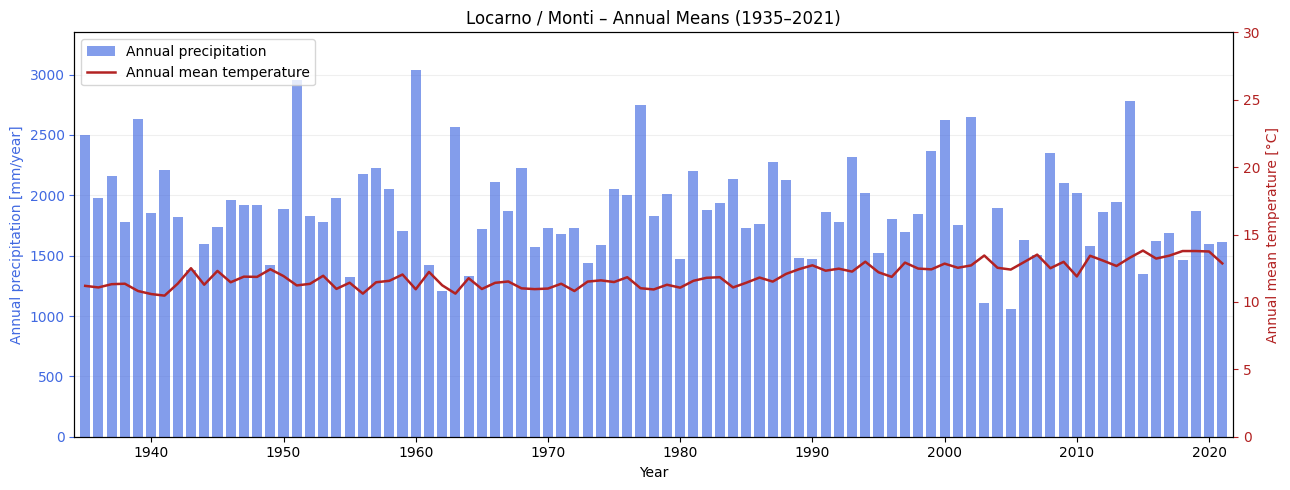

In [16]:
# Prepare data
annual_data = data_OTL.copy()
annual_data["reference_timestamp"] = pd.to_datetime(
    annual_data["reference_timestamp"]
)
annual_data = annual_data.set_index("reference_timestamp").sort_index()

columns = ["rhs150m0", "ths200m0"]
annual_data[columns] = annual_data[columns].apply(
    pd.to_numeric, errors="coerce"
)

# Calculate annual means; require 12 valid months per variable
annual = annual_data[columns].resample("YS").mean()
counts = annual_data[columns].resample("YS").count()
annual = annual.where(counts == 12)
annual["rhs150m0"] *= 12  # Convert mean monthly precipitation to annual total

# Create independent precipitation and temperature axes
fig, ax_p = plt.subplots(figsize=(13, 5))
ax_t = ax_p.twinx()

bars = ax_p.bar(
    annual.index, annual["rhs150m0"],
    width=280, color="royalblue", alpha=0.65,
    label="Mean monthly precipitation"
)
line, = ax_t.plot(
    annual.index, annual["ths200m0"],
    color="firebrick", linewidth=1.8,
    label="Annual mean temperature"
)

# Use a broad temperature range to soften visual fluctuations
# Both axes start at zero
ax_t.set_ylim(0, max(30, 5 * np.ceil(annual["ths200m0"].max() / 5)))
ax_p.set_ylim(0, 50 * np.ceil(annual["rhs150m0"].max() * 1.1 / 50))

ax_p.set_ylabel("Mean monthly precipitation [mm/month]", color="royalblue")
ax_t.set_ylabel("Annual mean temperature [°C]", color="firebrick")
ax_p.tick_params(axis="y", colors="royalblue")
ax_t.tick_params(axis="y", colors="firebrick")

ax_p.set_xlabel("Year")
ax_p.xaxis.set_major_locator(mdates.YearLocator(10))
ax_p.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_p.margins(x=0.005)
ax_p.set_axisbelow(True)
ax_p.grid(axis="y", alpha=0.2)

ax_p.set_ylabel("Annual precipitation [mm/year]", color="royalblue")

ax_p.legend(
    [bars, line],
    ["Annual precipitation", "Annual mean temperature"],
    loc="upper left"
)
ax_p.set_title(
    f"Locarno / Monti – Annual Means "
    f"({annual.index.year.min()}–{annual.index.year.max()})"
)

fig.tight_layout()

if save_figures:
    plt.savefig(path_outputs + "annual_means_precip_temp.png", dpi=600)

plt.show()

#### Question 2 [5 pts]
Which data did you chose and why? Make sure to state the url from which you downloaded the data, and to discuss the choice of the station that you selected.

### Task 3 - Melt model calibration 
Use the meteorological time series retrieved in Question 2 to calibrate the Degree Day Factor (DDF) of a simple temperature index model. Go back to the the lecture notes or refer again to the Glossary if you don’t recall what such a model is.

#### Question 3.1 [7 pts] 
What was your procedure to calibrate the DDF? Make sure to provide a step by step explanation and to mention any assumption.

#### Question 3.2 [6 pts]
What value (and unit) do you obtain for the calibrated DDF, and howdoes it compare to values reported in the literature? Make sure to have ”days” somewhere in the units for the ”Degree Day Factor”, and compare your result against at least two published DDF values (provide the corresponding references). Discuss what might be at the origin of the differences that you find (if any).

#### Question 3.3 [6 pts]
Reflect upon the various assumptions that were necessary for the cali- bration. Which assumptions are likely to introduce a bias? In what direction do the individual biases go, and which assumption are likely to introduce the largest biases?

### Task 4 - Mass balance reconstruction

#### Question 4 [7 pts]
What are the (i) cumulative and (ii) average glacier mass balance (in m w.e. and m w.e. $a^{−1}$, respectively) and what do you observe in the yearly time series? Check whether you can discern trends, and whether there are periods or individual years that stand out.

### Task 5 - Future projection

#### Question 5.1 [4 pts]
What was the glacier volume in 2021? Express you results in $km^3$.

#### Question 5.2 [6 pts]
Based on your projection, when (year) will the glacier have lost 50% of the volume it had in 2021? Use ”Hint 1” below, and discuss whether the resulting ”projection” is likely to be an under- or overestimate, and why.

#### Question 5.3 [4 pts]
Can you think of a strategy that avoids the simplification given in ”Hint 1”? Explain how you could avoid the assumption of a constant area, and what additional information, tools, or methods (if any) you would need for that.

## Assignment 2